In [3]:
# Cell 2 - Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              confusion_matrix, classification_report)
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings, os
warnings.filterwarnings('ignore')

os.makedirs('../reports/png', exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

print('Libraries loaded!')

Libraries loaded!


In [4]:
# Cell 3 - Load cleaned dataset
df = pd.read_csv('../data/cleaned_superstore.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Year'] = df['Order Date'].dt.year
df['Profit Margin'] = (df['Profit'] / df['Sales'].replace(0, np.nan) * 100).fillna(0).round(2)
df['Is Profitable'] = (df['Profit'] > 0).astype(int)
df['Has Discount'] = (df['Discount'] > 0)

print(f'Shape: {df.shape}')
df.head(3)

Shape: (6764, 25)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Profit Margin,Is Profitable,Has Discount
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136,2016,16.00,1,False
1,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714,2016,47.00,1,False
2,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164,2015,11.25,1,True


In [5]:
# Cell 4 - Descriptive statistics
numeric_cols = ['Sales', 'Profit', 'Discount', 'Quantity', 'Profit Margin']

desc = df[numeric_cols].describe().T
desc['skewness'] = df[numeric_cols].skew()
desc['mode'] = df[numeric_cols].mode().iloc[0]

print('=' * 60)
print('  DESCRIPTIVE STATISTICS')
print('=' * 60)
print(desc[['mean', '50%', 'mode', 'std', 'skewness']].round(2)
      .rename(columns={'50%': 'median'}))

  DESCRIPTIVE STATISTICS
                mean  median   mode    std  skewness
Sales          68.00   34.80  12.96  85.79      2.35
Profit         11.67    7.94   0.00  13.50      0.86
Discount        0.10    0.00   0.00   0.11      0.35
Quantity        3.37    3.00   2.00   1.87      1.00
Profit Margin  26.69   31.00  48.00  17.73     -0.82


In [6]:
# Cell 5 - Hypothesis Test 1: T-Test
# H0: Mean profit is the SAME for discounted vs non-discounted orders
# H1: Mean profit DIFFERS between discounted vs non-discounted orders

group_discount    = df[df['Has Discount'] == True]['Profit']
group_no_discount = df[df['Has Discount'] == False]['Profit']

t_stat, p_value = stats.ttest_ind(group_discount, group_no_discount, equal_var=False)

print('=' * 60)
print('  T-TEST: Profit (Discounted vs Non-Discounted Orders)')
print('=' * 60)
print(f'Discounted orders   - mean profit: ${group_discount.mean():.2f}  (n={len(group_discount)})')
print(f'Non-discounted      - mean profit: ${group_no_discount.mean():.2f}  (n={len(group_no_discount)})')
print(f'\nT-statistic: {t_stat:.4f}')
print(f'P-value:     {p_value:.6f}')

alpha = 0.05
if p_value < alpha:
    print(f'\nResult: REJECT H0 (p < {alpha}) - the difference in profit IS statistically significant.')
    print('Business implication: Discounting measurably changes profit outcomes.')
    print('Recommend reviewing discount policy on low-margin sub-categories.')
else:
    print(f'\nResult: FAIL TO REJECT H0 (p >= {alpha}) - no statistically significant difference found.')
    print('Business implication: Discounting alone does not explain profit variation;')
    print('other factors (category, region) likely play a bigger role.')

  T-TEST: Profit (Discounted vs Non-Discounted Orders)
Discounted orders   - mean profit: $8.18  (n=3177)
Non-discounted      - mean profit: $14.76  (n=3587)

T-statistic: -20.5715
P-value:     0.000000

Result: REJECT H0 (p < 0.05) - the difference in profit IS statistically significant.
Business implication: Discounting measurably changes profit outcomes.
Recommend reviewing discount policy on low-margin sub-categories.


In [7]:
# Cell 6 - Hypothesis Test 2: Chi-Square Test of Independence
# H0: Region and Category are INDEPENDENT (no association)
# H1: Region and Category are ASSOCIATED

contingency = pd.crosstab(df['Region'], df['Category'])
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency)

print('=' * 60)
print('  CHI-SQUARE TEST: Region vs Category')
print('=' * 60)
print('Contingency table (order counts):')
print(contingency)
print(f'\nChi-square statistic: {chi2:.4f}')
print(f'Degrees of freedom:   {dof}')
print(f'P-value:              {p_val_chi:.6f}')

if p_val_chi < alpha:
    print(f'\nResult: REJECT H0 (p < {alpha}) - Region and Category ARE associated.')
    print('Business implication: product mix preference varies by region.')
    print('Recommend region-specific inventory/marketing strategy.')
else:
    print(f'\nResult: FAIL TO REJECT H0 (p >= {alpha}) - no significant association found.')
    print('Business implication: category demand is consistent nationwide,')
    print('a single national merchandising strategy is reasonable.')

  CHI-SQUARE TEST: Region vs Category
Contingency table (order counts):
Category  Furniture  Office Supplies  Technology
Region                                          
Central         143              946         271
East            359             1297         269
South           206              718         174
West            451             1551         379

Chi-square statistic: 64.3267
Degrees of freedom:   6
P-value:              0.000000

Result: REJECT H0 (p < 0.05) - Region and Category ARE associated.
Business implication: product mix preference varies by region.
Recommend region-specific inventory/marketing strategy.


In [8]:
# Cell 7 - 95% Confidence Interval for Mean Profit Margin
data = df['Profit Margin'].dropna()
mean = data.mean()
sem = stats.sem(data)
ci_low, ci_high = stats.t.interval(0.95, len(data) - 1, loc=mean, scale=sem)

print('=' * 60)
print('  95% CONFIDENCE INTERVAL: Mean Profit Margin')
print('=' * 60)
print(f'Sample mean profit margin: {mean:.2f}%')
print(f'95% CI: [{ci_low:.2f}%, {ci_high:.2f}%]')
print(f'\nInterpretation: We are 95% confident the TRUE average profit margin')
print(f'across all Superstore orders falls between {ci_low:.2f}% and {ci_high:.2f}%.')

  95% CONFIDENCE INTERVAL: Mean Profit Margin
Sample mean profit margin: 26.69%
95% CI: [26.26%, 27.11%]

Interpretation: We are 95% confident the TRUE average profit margin
across all Superstore orders falls between 26.26% and 27.11%.


In [9]:
# Cell 8 - Convert to time series & resample monthly
ts = df.set_index('Order Date').sort_index()
monthly_sales = ts['Sales'].resample('MS').sum()

print(f'Time series range: {monthly_sales.index.min()} to {monthly_sales.index.max()}')
print(f'Number of months: {len(monthly_sales)}')
monthly_sales.head()

Time series range: 2014-01-01 00:00:00 to 2017-12-01 00:00:00
Number of months: 48


Order Date
2014-01-01    3640.535
2014-02-01    2191.378
2014-03-01    7829.270
2014-04-01    6631.275
2014-05-01    6229.891
Freq: MS, Name: Sales, dtype: float64

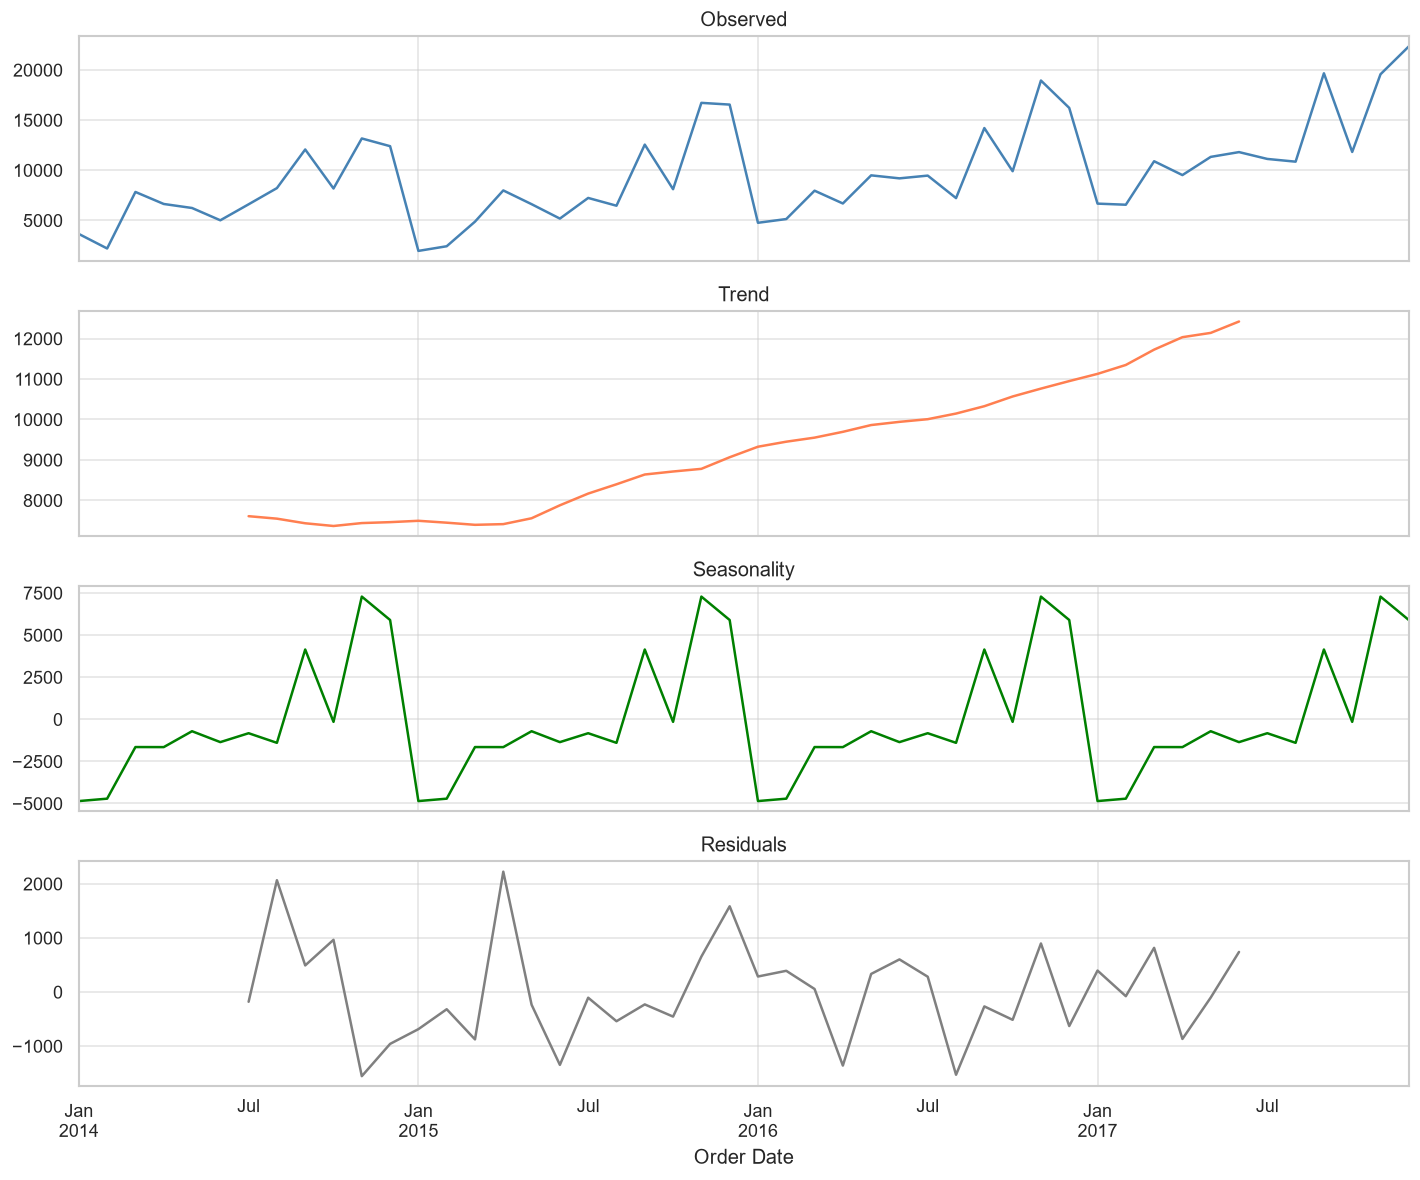

Saved: 10_timeseries_decomposition.png


In [10]:
# Cell 9 - Decompose into Trend, Seasonality, Residuals
if len(monthly_sales) >= 24:
    decomposition = seasonal_decompose(monthly_sales, model='additive', period=12)

    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    decomposition.observed.plot(ax=axes[0], title='Observed', color='steelblue')
    decomposition.trend.plot(ax=axes[1], title='Trend', color='coral')
    decomposition.seasonal.plot(ax=axes[2], title='Seasonality', color='green')
    decomposition.resid.plot(ax=axes[3], title='Residuals', color='grey')
    plt.tight_layout()
    plt.savefig('../reports/png/10_timeseries_decomposition.png', bbox_inches='tight')
    plt.show()
    print('Saved: 10_timeseries_decomposition.png')
else:
    print(f'Skipping decomposition - need at least 24 months of data, have {len(monthly_sales)}.')

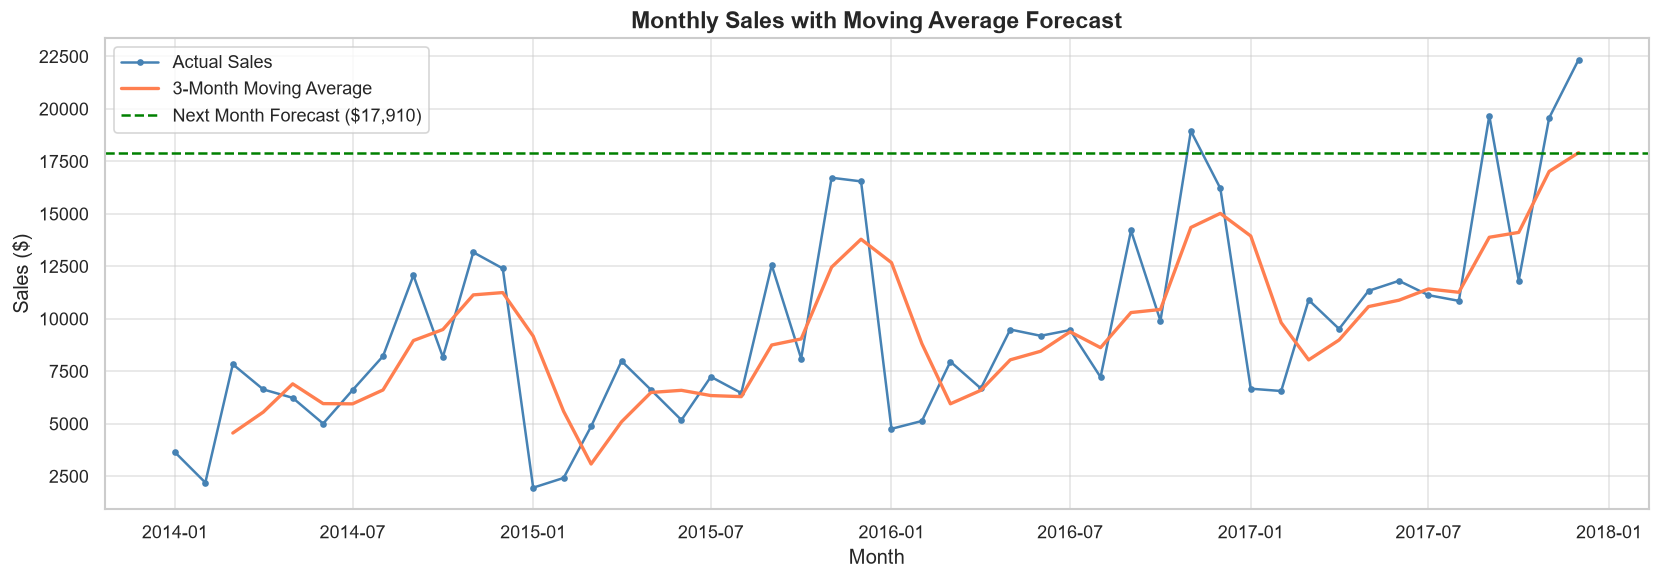

Next month forecast (simple 3-month moving average): $17,910.30


In [11]:
# Cell 10 - Simple Moving Average Forecast
window = 3
moving_avg = monthly_sales.rolling(window=window).mean()

# Naive next-month forecast = average of last `window` months
next_month_forecast = monthly_sales.tail(window).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_sales.index, monthly_sales.values, label='Actual Sales',
        color='steelblue', marker='o', markersize=3)
ax.plot(moving_avg.index, moving_avg.values, label=f'{window}-Month Moving Average',
        color='coral', linewidth=2)
ax.axhline(next_month_forecast, color='green', linestyle='--',
           label=f'Next Month Forecast (${next_month_forecast:,.0f})')
ax.set_title('Monthly Sales with Moving Average Forecast', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Sales ($)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/png/11_moving_average_forecast.png', bbox_inches='tight')
plt.show()
print(f'Next month forecast (simple {window}-month moving average): ${next_month_forecast:,.2f}')

In [12]:
# Cell 11 - Prepare customer-level features
customer_features = df.groupby('Customer ID').agg(
    total_sales=('Sales', 'sum'),
    total_profit=('Profit', 'sum'),
    total_quantity=('Quantity', 'sum'),
    order_count=('Order ID', 'nunique'),
    avg_discount=('Discount', 'mean')
).reset_index()

feature_cols = ['total_sales', 'total_profit', 'total_quantity', 'order_count', 'avg_discount']
X_cluster = customer_features[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f'Customers: {len(customer_features)}')
customer_features.head()

Customers: 787


,Customer ID,total_sales,total_profit,total_quantity,order_count,avg_discount
0,AA-10315,596.980,79.8089,22,5,0.075000
1,AA-10375,556.410,162.3870,39,9,0.085714
2,AA-10480,652.732,115.3212,26,4,0.022222
3,AA-10645,702.860,109.1827,37,6,0.058333
4,AB-10015,322.216,12.4785,9,2,0.100000


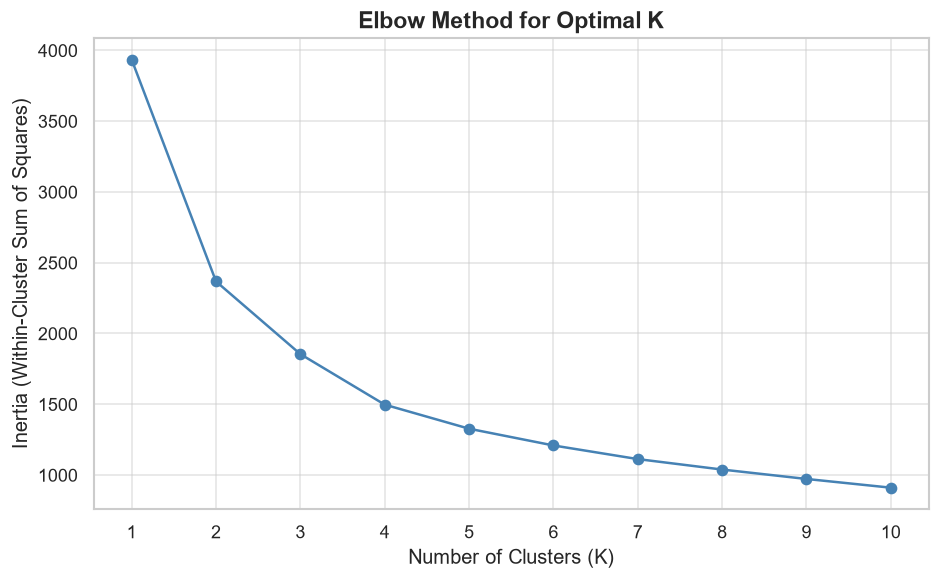

Saved: 12_elbow_method.png
Look for the "elbow" - the point where inertia stops dropping sharply.


In [13]:
# Cell 12 - Elbow Method to find optimal K
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), inertias, marker='o', color='steelblue')
ax.set_title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.savefig('../reports/png/12_elbow_method.png', bbox_inches='tight')
plt.show()
print('Saved: 12_elbow_method.png')
print('Look for the "elbow" - the point where inertia stops dropping sharply.')

In [14]:
# Cell 13 - Fit K-Means with chosen K
# Based on the elbow plot above, 4 clusters is a common, interpretable choice for customer segmentation
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customer_features['Cluster'] = kmeans.fit_predict(X_scaled)

print(f'Fitted K-Means with K={optimal_k}')
print(customer_features['Cluster'].value_counts().sort_index())

Fitted K-Means with K=4
Cluster
0    234
1    107
2    175
3    271
Name: count, dtype: int64


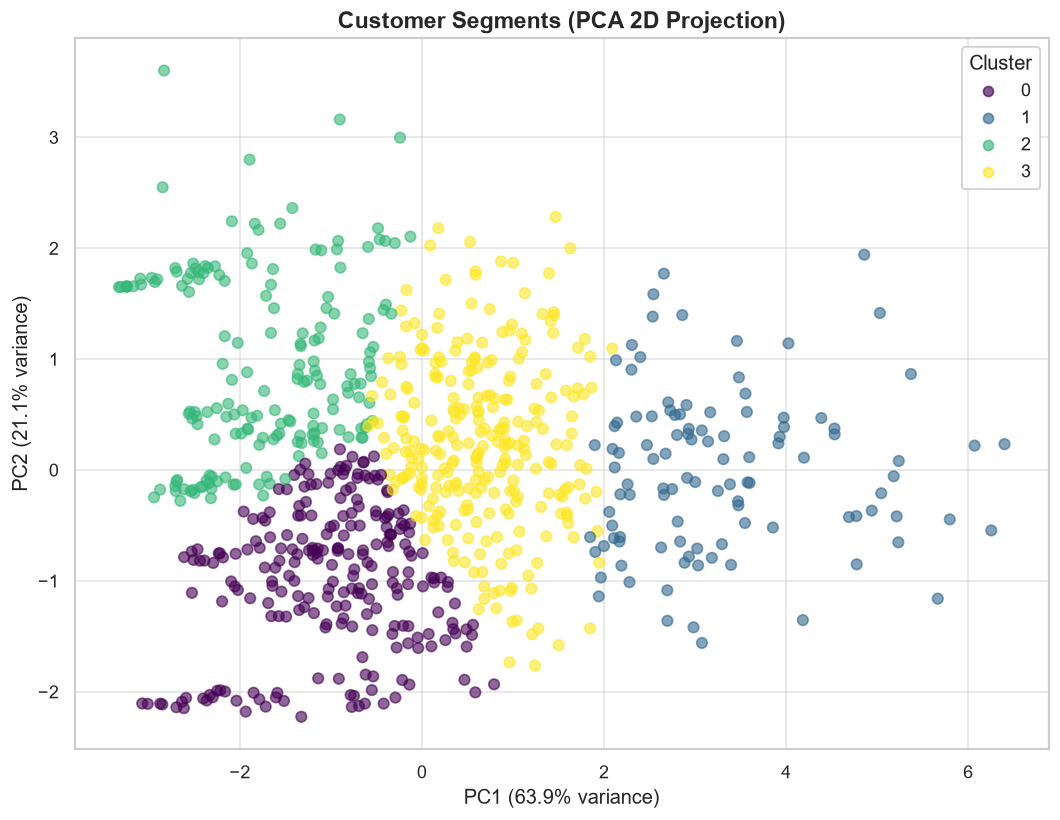

Saved: 13_pca_cluster_visualization.png
Total variance explained by 2 components: 84.9%


In [15]:
# Cell 14 - Visualize clusters using PCA (2D)
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(pca_coords[:, 0], pca_coords[:, 1],
                      c=customer_features['Cluster'], cmap='viridis',
                      alpha=0.6, s=40)
ax.set_title('Customer Segments (PCA 2D Projection)', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
legend1 = ax.legend(*scatter.legend_elements(), title='Cluster')
ax.add_artist(legend1)
plt.tight_layout()
plt.savefig('../reports/png/13_pca_cluster_visualization.png', bbox_inches='tight')
plt.show()
print('Saved: 13_pca_cluster_visualization.png')
print(f'Total variance explained by 2 components: {sum(pca.explained_variance_ratio_)*100:.1f}%')

In [16]:
# Cell 15 - Profile each segment with recommendations
profile = customer_features.groupby('Cluster')[feature_cols].mean().round(2)
profile['customer_count'] = customer_features['Cluster'].value_counts().sort_index()

# Rank clusters by total_sales to assign meaningful tier labels dynamically
ranked = profile['total_sales'].rank(ascending=False).astype(int)
tier_names = {1: 'Champions (Highest Value)', 2: 'Loyal / High Potential',
              3: 'Developing', 4: 'At-Risk / Low Engagement'}
profile['Tier'] = ranked.map(tier_names)

print('=' * 70)
print('  CUSTOMER SEGMENT PROFILES')
print('=' * 70)
print(profile)

print('\nRecommendations:')
for cluster_id, row in profile.iterrows():
    print(f"\nCluster {cluster_id} - {row['Tier']} ({int(row['customer_count'])} customers)")
    if row['Tier'].startswith('Champions'):
        print('  -> Prioritize retention: loyalty perks, early access to new products.')
    elif row['Tier'].startswith('Loyal'):
        print('  -> Upsell/cross-sell campaigns to grow their basket size.')
    elif row['Tier'].startswith('Developing'):
        print('  -> Targeted promotions to increase purchase frequency.')
    else:
        print('  -> Re-engagement campaigns; investigate churn risk and discount sensitivity.')

  CUSTOMER SEGMENT PROFILES
         total_sales  total_profit  total_quantity  order_count  avg_discount  \
Cluster                                                                         
0             345.30         75.58           19.62         3.87          0.05   
1            1265.66        219.22           56.55         8.21          0.09   
2             308.63         36.08           15.62         3.33          0.15   
3             700.16        116.16           34.84         6.22          0.11   

         customer_count                       Tier  
Cluster                                             
0                   234                 Developing  
1                   107  Champions (Highest Value)  
2                   175   At-Risk / Low Engagement  
3                   271     Loyal / High Potential  

Recommendations:

Cluster 0 - Developing (234 customers)
  -> Targeted promotions to increase purchase frequency.

Cluster 1 - Champions (Highest Value) (107 customer

In [17]:
# Cell 16 - Feature engineering for predictive model
model_df = df[['Sales', 'Quantity', 'Discount', 'Category', 'Sub-Category',
               'Segment', 'Region', 'Ship Mode', 'Is Profitable']].copy()

# One-hot encode categorical columns
model_df_encoded = pd.get_dummies(
    model_df,
    columns=['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode'],
    drop_first=True
)

X = model_df_encoded.drop(columns=['Is Profitable'])
y = model_df_encoded['Is Profitable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set: {X_train.shape}, Test set: {X_test.shape}')
print(f'Class balance (train): {y_train.value_counts(normalize=True).round(3).to_dict()}')

Train set: (5411, 28), Test set: (1353, 28)
Class balance (train): {1: 0.926, 0: 0.074}


In [18]:
# Cell 17 - Train Logistic Regression
model = LogisticRegression(max_iter=2000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('Model trained!')

Model trained!


  MODEL EVALUATION
Accuracy:  0.9438
Precision: 0.9448
Recall:    0.9976

Classification Report:
              precision    recall  f1-score   support

        Loss       0.90      0.28      0.42       101
  Profitable       0.94      1.00      0.97      1252

    accuracy                           0.94      1353
   macro avg       0.92      0.64      0.70      1353
weighted avg       0.94      0.94      0.93      1353



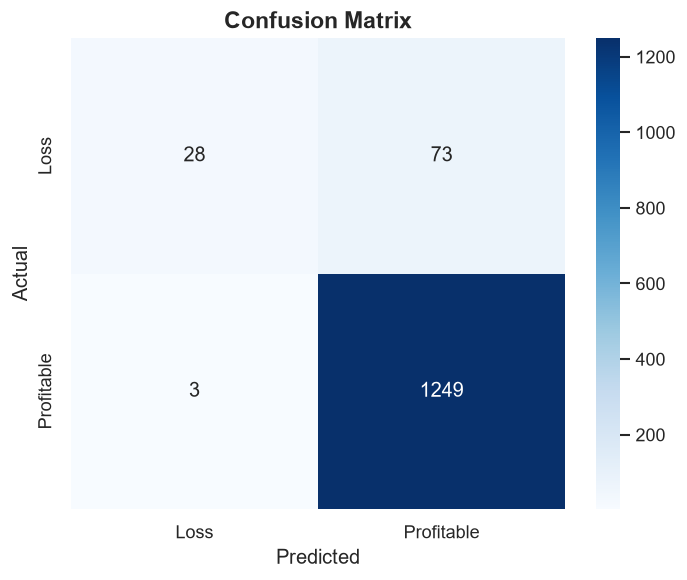

Saved: 14_confusion_matrix.png


In [19]:
# Cell 18 - Evaluate the model
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
cm   = confusion_matrix(y_test, y_pred)

print('=' * 60)
print('  MODEL EVALUATION')
print('=' * 60)
print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Loss', 'Profitable']))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Loss', 'Profitable'],
            yticklabels=['Loss', 'Profitable'], ax=ax)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('../reports/png/14_confusion_matrix.png', bbox_inches='tight')
plt.show()
print('Saved: 14_confusion_matrix.png')

  TOP 3 MOST IMPORTANT FEATURES
Discount                       | coef=-10.308 | decreases odds of profitability
Sub-Category_Storage           | coef=-2.837 | decreases odds of profitability
Category_Office Supplies       | coef=+2.551 | increases odds of profitability


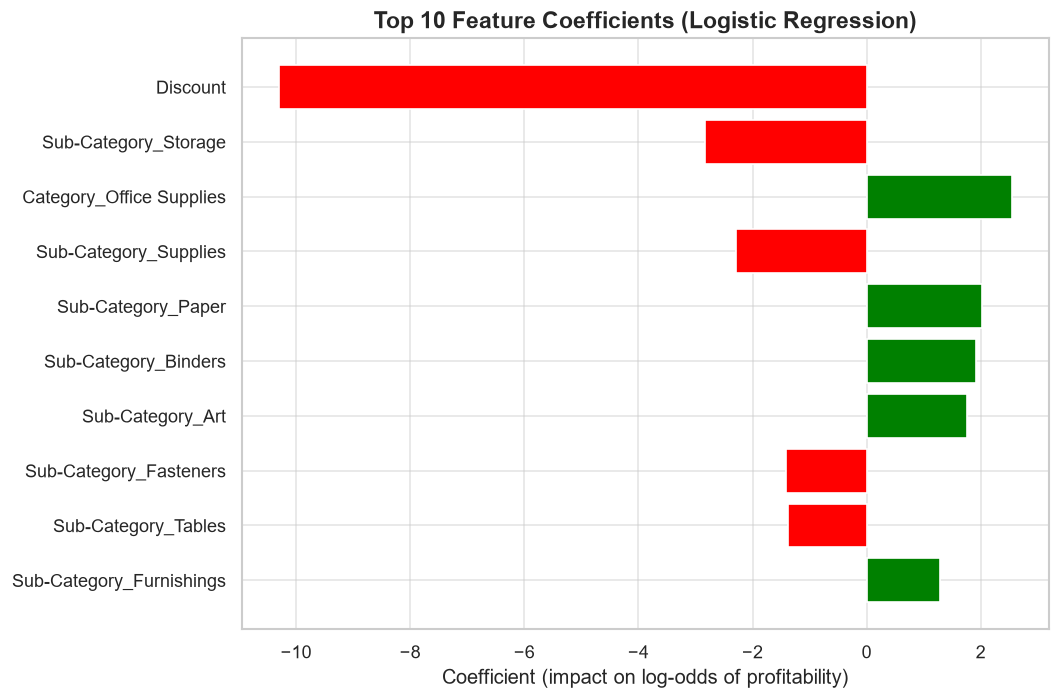

Saved: 15_feature_importance.png


In [20]:
# Cell 19 - Top 3 important features
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False)

top3 = coef_df.head(3)
print('=' * 60)
print('  TOP 3 MOST IMPORTANT FEATURES')
print('=' * 60)
for _, row in top3.iterrows():
    direction = 'increases' if row['coefficient'] > 0 else 'decreases'
    print(f"{row['feature']:30s} | coef={row['coefficient']:+.3f} | {direction} odds of profitability")

fig, ax = plt.subplots(figsize=(9, 6))
top10 = coef_df.head(10)
colors = ['green' if c > 0 else 'red' for c in top10['coefficient']]
ax.barh(top10['feature'], top10['coefficient'], color=colors)
ax.set_title('Top 10 Feature Coefficients (Logistic Regression)', fontsize=14, fontweight='bold')
ax.set_xlabel('Coefficient (impact on log-odds of profitability)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/png/15_feature_importance.png', bbox_inches='tight')
plt.show()
print('Saved: 15_feature_importance.png')

In [21]:
# Cell 20 - Task 4 Summary
print('=' * 60)
print('  TASK 4 SUMMARY')
print('=' * 60)
print(f'Statistical tests run: T-test, Chi-square, 95% Confidence Interval')
print(f'Time series: {len(monthly_sales)} months analyzed, decomposed + forecasted')
print(f'Customer segments: {optimal_k} clusters identified via K-Means')
print(f'Predictive model: Logistic Regression, Accuracy={acc:.2%}, Precision={prec:.2%}, Recall={rec:.2%}')
print('\nAll charts saved to reports/png/')

  TASK 4 SUMMARY
Statistical tests run: T-test, Chi-square, 95% Confidence Interval
Time series: 48 months analyzed, decomposed + forecasted
Customer segments: 4 clusters identified via K-Means
Predictive model: Logistic Regression, Accuracy=94.38%, Precision=94.48%, Recall=99.76%

All charts saved to reports/png/
